# Simple RAG pipeline with Qdrant and Langchain

Install 
```bash
uv add langchain langchain-text-splitters langchain-community bs4
```

Make sure to auto reload dependencies to prevent restarting kernel while you add them along the way

In [1]:
%load_ext autoreload
%autoreload 2

## Setup Langsmith Tracing

Install langchain 
```bash
uv add langchain_openai
```

1. Generate Langsmith API key
2. Create an environment variable with the API key
3. Load env and test with a simple agent


In [2]:
# Initialize Langsmith tracing
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
try:
    os.getenv("LANGSMITH_ENDPOINT")
    os.getenv("LANGSMITH_TRACING")
except Exception as e:
    print("Error loading LANGSMITH_TRACING:", e)


## Now, we need to select three components from LangChain's suite of integration
- Chat Model
- Embedding 
- Vector Store

### 1. Chat Model
We'll be using Open Router's API Keys to intialize our chat model since it's free. We'll use gpt-4o-mini as our chat model.

Just remember to define
- `base_url`
- `api_key`
- `model` 

In [3]:
import os 
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

model = ChatOpenAI( 
    api_key = os.getenv("OPENROUTER_API_KEY"),  # We'll be using Open Router's API KEY
    base_url="https://openrouter.ai/api/v1",     
    model = "gpt-4o-mini",  # select the model you want to use
)



d:\Projects\simple rag project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Let's test the chat model 
response = model.invoke("Hi, what is langchain?").content
response

'LangChain is an open-source framework designed for building applications with large language models (LLMs). It provides a set of components and abstractions that simplify the development process when integrating LLMs into applications. Key features of LangChain include:\n\n1. **Modular Components**: LangChain offers a modular architecture with components for various tasks—such as text generation, summarization, question answering, and prompt management—that can be easily combined.\n\n2. **Integrations**: The framework supports integration with various external tools and services, like databases, APIs, and other machine learning models, enabling developers to create more complex applications.\n\n3. **Chain Construction**: Developers can create chains of operations that allow for more sophisticated interactions with LLMs, such as processing inputs through multiple steps, managing state, and handling user interactions.\n\n4. **Memory and Context**: LangChain supports features for maintai

### 2. Embeddings model
We'll be using sentence transformer since it's freely available and can be used via langchain-huggingface. We need to install `langchain-huggingface` first.
```bash
uv add sentence-transformers
uv add langchain-huggingface

```

In [5]:
# import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

### 3. Vector Store
We'll be using Qdrant as our vector store. We'll run the qdrant client using Docker. First install langchain-qdrant.
```bash
uv add langchain-qdrant
uv add qdrant-client
```

Then we'll be running our qdrant client in docker.
```bash
docker pull qdrant/qdrant 
docker run -p 6333:6333 --name qdrant qdrant/qdrant
```

In [6]:
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# Initialize Qdrant client which is running locally via Docker
client = QdrantClient(host="localhost", port=6333)

# Get embedding vector size
vector_size = len(embeddings.embed_query("sample text"))

# Create collection if it doesn't exist
if not client.collection_exists("test"):
    client.create_collection(
        collection_name="test",
        vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE)
    )

# Initialize Qdrant Vector Store in LangChain
vector_store = QdrantVectorStore(
    client=client,
    collection_name="test",
    embedding=embeddings,    # sbert embeddings
)

## 1. Indexing
Indexing commonly works as follows:
1. Load: First we need to load our data. This is done with **Document Loaders.** `langchain_community.document_loaders`
2. Split: Text splitters break large Documents into smaller **chunks**. This is useful both for indexing data and passing it into a model, as large chunks are harder to search over and won’t fit in a model’s finite context window. `langchain_text_splitters`
3. Store: We need somewhere to store and index our splits, so that they can be searched over later. This is often done using a VectorStore and Embeddings model. We are using Qdrant as vector store and sentence transformer as embeddings model.

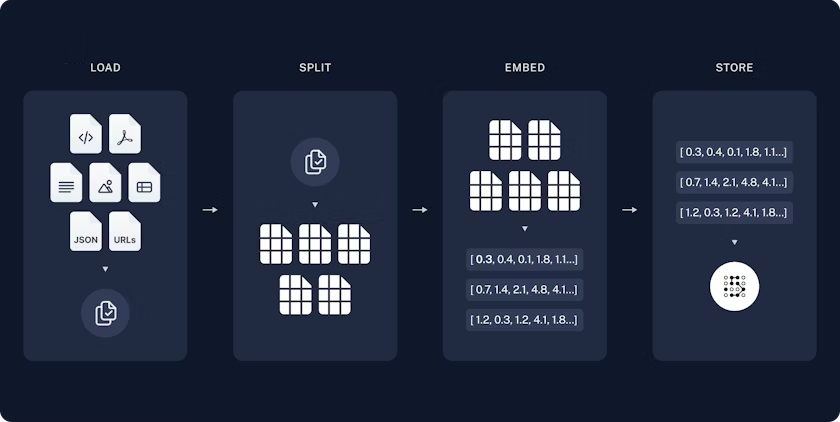

### Loading documents
We'll be using langchain_community's PDFPlumberLoader to load PDF documents. It handles layouts better than PyPDFLoader, especially for documents with tables or complex formatting.

In [7]:
# Document path 
pdf_path = r"D:\Projects\simple rag project\sample employee handbook.pdf "

In [8]:
# to load PDF documents (handles layouts better than PyPDFLoader like tables)
from langchain_community.document_loaders import PDFPlumberLoader   
 # to make langchain documents that can be processed by text splitters 
from langchain_core.documents import Document  
# for text splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter 

loader = PDFPlumberLoader(pdf_path)
docs = loader.load()


In [9]:
print(docs[0].page_content[:100])

SAMPLE EMPLOYEE HANDBOOK
©2004 National Council of Nonprofit Associations
May be duplicated, with at


### Splitting text 
- Our loaded document can have a lot of characters which is too long to fit into the context window of many models. 
- Even for those models that could fit the full post in their context window, models can struggle to find information in very long inputs.
- To handle this we’ll split the Document into chunks for embedding and vector storage. 

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter  # for text splitting

# Let's split the documents into smaller chunks for better processing
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # size of each chunk in characters
    chunk_overlap=200, # i.e. 20% overlap
    separators=["\n\n", "\n", " ", ""]   # separators to split on
)

In [11]:
all_splits = text_splitter.split_documents(docs)
print(f"Number of document chunks: {len(all_splits)}")

Number of document chunks: 90


### Storing Documents in Vector Store

In [12]:
document_ids = vector_store.add_documents(all_splits)
print(document_ids[:3])

['1715790c1e484ceba9addacc4f378f9a', '5719d1c19c0a4d0089a1bce0b096375e', 'ce239bddab814136b86ab7a4d70aefe2']


## 2. Retrieval and Question Answering
We have indexed our documents into Qdrant vector store. Now we can use this indexed data to answer questions.

RAG applications commonly work as follows:
- **Retrieve**: Given a user input, relevant splits are retrieved from storage using a Retriever.
- **Generate**: A model produces an answer using a prompt that includes both the question with the retrieved data

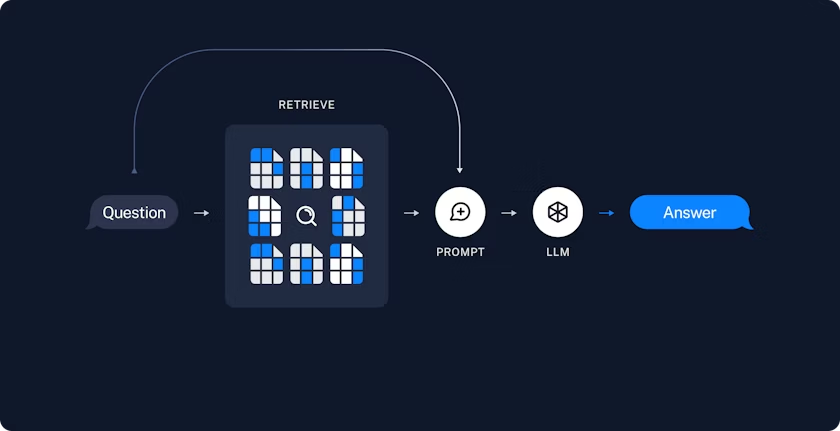

There are two approaches of building a RAG Application:
- A **RAG agent** that executes searches with a simple tool. This is a good general-purpose implementation.
- A **two-step RAG chain** that uses just a single LLM call per query. This is a fast and effective method for simple queries.

In this project we'll be building a RAG agent. We'll assemble a minimal RAG agent by implementing a tool that wraps our vector store. The simplest way to create a tool is with the `@tool` decorator. By default, the function’s docstring becomes the tool’s description that helps the model understand when to use it. We customize tool properties using various parameters such as:

| Parameter                   | Type                                         | Purpose / Usage                                                                                                                                                      |
| --------------------------- | -------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`name`**                  | `str`                                        | Sets a custom tool name (defaults to the function name). Useful when you want a cleaner or more descriptive tool name for the LLM.                                   |
| **`description`**           | `str`                                        | Overrides the function’s docstring as the tool description. This is *what the LLM sees* when deciding whether to use the tool.                                       |
| **`args_schema`**           | `pydantic.BaseModel` subclass                | Defines structured, validated input arguments (types, defaults, etc.). Great for complex parameterized tools.                                                        |
| **`return_direct`**         | `bool`                                       | If `True`, the tool’s output is returned directly to the user, bypassing the LLM’s reasoning step. Usually used for retrieval or final answer tools.                 |
| **`response_format`**       | `"content_only"` or `"content_and_artifact"` | Controls the return type: just a string (default) to the llm or tuple `(content, artifact)` lets you return both a string for the LLM and a Python object for downstream use.

First, we'll define a retrieval tool that queries our Qdrant vector store. This tool will take a user query, perform a similarity search in the vector store, and return the most relevant document chunks as context for answering the question.

If it couldn't find the relevant information it will return empty text which let's llm know the information was not found and it will use the web search tool.


In [13]:
from langchain.tools import tool

SIMILARITY_THRESHOLD = 0.4

# PDF retrieval tool
@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """
    Retrieve information to help answer a query from internal PDFs.
    """
    retrieved_docs = vector_store.similarity_search_with_score(query, k=2)
    
    # Check if similarity is above threshold
    if retrieved_docs and all(score >= SIMILARITY_THRESHOLD for _, score in retrieved_docs):
        serialized = "\n\n".join(
            f"Source: {doc.metadata}\n\nContent: {doc.page_content}" 
            for doc, score in retrieved_docs
        )
        return serialized, retrieved_docs
    
    # If PDF retrieval is not confident, return empty string so agent can decide
    return "", []

Our web search tool will 


In [14]:
# Web search tool
from ddgs import DDGS
from langchain.tools import tool

def web_search_func(query: str, num_results: int = 5) -> str:
    """Actual web search logic with safe key access."""
    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=num_results))
    
    lines = []
    for r in results:
        title = r.get("title", "")
        snippet = r.get("snippet", "")  # use .get() to avoid KeyError
        href = r.get("href", "")
        lines.append(f"{title}\n{snippet}\n{href}")
    
    return "\n".join(lines)


@tool
def web_search(query: str) -> str:
    """Search the web and return top results."""
    return web_search_func(query)




Now, we have our tool ready to be used by the RAG agent. Then, let's create the RAG agent using this tool.

In [ ]:

# Create ageent with both tools
from langchain.agents import create_agent

tools = [retrieve_context, web_search]

disclaimer = """
For detailed information, please refer to your company's HR department or internal resources.
"""

prompt = f"""
You have access to two tools:
1. retrieve_context: Retrieves context from internal PDFs.
2. web_search: Searches the web for relevant information.

Use retrieve_context first. 
If it returns empty or low-confidence results, use web_search.
Make sure to add a header, "Web Search Results:" before providing web search results.
Provide this disclaimer, {disclaimer} at the end after "Web Search Results:" if you had to use web search.
"""

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=prompt,
)


Let's test our RAG agent with a sample question

In [18]:
# Search query
from IPython.display import display, Markdown

query = (
    "How to climb up in position and get promoted?"
)


for event in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    message = event["messages"][-1].content
    if message:
        display(Markdown(message))

How to climb up in position and get promoted?

How To Get Promoted at Work: 9 Effective Strategies | Indeed.com

https://www.indeed.com/career-advice/career-development/how-to-get-promoted-at-work
How to Get Promoted at Work With These Tips to Keep You On Track

https://theluxauthority.com/how-to-get-promoted/
Tips to Get Promoted at Work

https://www.hitechwork.com/tips-to-get-promoted-at-work/
How to Get Promoted - 6 Tips

https://bemycareercoach.com/career-development/job-promotion/how-to-get-promoted.html
5 Tips to Get Promoted at Work - The WERK LIFE

https://www.thewerklife.com/job-promotion-work/

Web Search Results:

1. **How To Get Promoted at Work: 9 Effective Strategies** - This article discusses various strategies, including understanding your company’s promotion process, seeking regular feedback, demonstrating leadership qualities, and building strong relationships with team members. [Read more](https://www.indeed.com/career-advice/career-development/how-to-get-promoted-at-work)

2. **How to Get Promoted at Work With These Tips to Keep You On Track** - This post outlines practical steps like taking initiative, improving your skills, and effectively communicating your accomplishments. [Read more](https://theluxauthority.com/how-to-get-promoted/)

3. **Tips to Get Promoted at Work** - This article provides several actionable tips on how to enhance your visibility and value within the organization which can lead to a promotion. [Read more](https://www.hitechwork.com/tips-to-get-promoted-at-work/)

4. **How to Get Promoted - 6 Tips** - It covers key areas such as understanding the expectations of the role you aspire to, networking, and showing consistent performance. [Read more](https://bemycareercoach.com/career-development/job-promotion/how-to-get-promoted.html)

5. **5 Tips to Get Promoted at Work - The WERK LIFE** - This piece emphasizes the importance of advocacy, finding a mentor, and developing a personal brand in order to achieve promotion. [Read more](https://www.thewerklife.com/job-promotion-work/)

I couldn't find relevant information from the document. For detailed information, please refer to your company's HR department or internal resources.